In [14]:
# If you are using google colab, you can mount your google drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Fine-tuning
This notebook demonstrates fine-tuning RamanFoundation on the Bacteria-ID dataset from Ho et al. (2019).

In [15]:
# From https://github.com/csho33/bacteria-ID
!unzip '/content/drive/My Drive/data.zip'

unzip:  cannot find or open /content/drive/My Drive/data.zip, /content/drive/My Drive/data.zip.zip or /content/drive/My Drive/data.zip.ZIP.


In [16]:
# This may be colab-specific. You may need to adapt this if you are running locally
!pip install tf_keras

!export TF_USE_LEGACY_KERAS=1
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf #importing tensorflow after setting the environment variable is important

import tensorflow as tf
import tf_keras as keras
print(tf.__version__)
print(keras.__version__)

!pip install tensorflow-addons

2.20.0
2.20.0
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [17]:
import os
import numpy as np  # np.random.random
import matplotlib.pyplot as plt  # graphs
import datetime  # tensorboard logs naming

In [18]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

data_dir = '/content/drive/My Drive/Tesi_Raman/Datasets/Processed/1000_pt/FullRange/Min-Max/'
file_path = data_dir + 'IBD_1000pt_Labeled.npz'

print(f"Caricamento dataset da: {file_path}")
data = np.load(file_path)

# Estrae dinamicamente X e y basandosi sulle chiavi presenti nel file .npz
keys = data.files
print(f"Chiavi trovate nel file npz: {keys}")

# Estraiamo specificamente 'spectra' e 'labels'
X_all = data['spectra'] if 'spectra' in keys else data['X']
y_all = data['labels'] if 'labels' in keys else data['y']

# Assicura che X abbia la forma (Samples, 1000, 1) per la rete Conv1D
if len(X_all.shape) == 2:
    X_all = np.expand_dims(X_all, axis=-1)

print(f"Dimensioni totali -> X: {X_all.shape}, y: {y_all.shape}")

# Dividiamo in set di training/finetuning (85%) e test (15%)
# Il k-fold verrà poi applicato all'85% di finetuning
x_finetune, x_test, y_finetune, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)

print(f"Dimensioni Finetune (per k-fold): X={x_finetune.shape}, y={y_finetune.shape}")
print(f"Dimensioni Test finale: X={x_test.shape}, y={y_test.shape}")

# Variabili dummy per mantenere compatibilità con il resto del codice
x_reference, y_reference = None, None


Caricamento dataset da: /content/drive/My Drive/Tesi_Raman/Datasets/Processed/1000_pt/FullRange/Min-Max/IBD_1000pt_Labeled.npz
Chiavi trovate nel file npz: ['spectra', 'wavelengths', 'labels', 'groups']
Dimensioni totali -> X: (228, 1000, 1), y: (228,)
Dimensioni Finetune (per k-fold): X=(193, 1000, 1), y=(193,)
Dimensioni Test finale: X=(35, 1000, 1), y=(35,)


In [19]:
class ResNet34Old:
    """Resnet34 class.
        Responsible for the Resnet 34 architecture.
    Modified from
    https://www.analyticsvidhya.com/blog/2021/08/how-to-code-your-resnet-from-scratch-in-tensorflow/#h2_2.
        View their website for more information.
    """
    def __init__(self):
        self.model = None

    def identity_block(self, x, filter):
        # copy tensor to variable called x_skip
        x_skip = x
        # Layer 1
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        x = tf.keras.layers.Activation("relu")(x)
        # Layer 2
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        # Add Residue
        x = tf.keras.layers.Add()([x, x_skip])
        x = tf.keras.layers.Activation("relu")(x)
        return x

    def convolutional_block(self, x, filter):
        # copy tensor to variable called x_skip
        x_skip = x
        # Layer 1
        x = tf.keras.layers.Conv1D(filter, 3, padding="same", strides=2)(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        x = tf.keras.layers.Activation("relu")(x)
        # Layer 2
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        # Processing Residue with conv(1,1)
        x_skip = tf.keras.layers.Conv1D(filter, 1, strides=2)(x_skip)
        # Add Residue
        x = tf.keras.layers.Add()([x, x_skip])
        x = tf.keras.layers.Activation("relu")(x)
        return x

    # CHANGED: Default shape to include channel dimension
    def __call__(self, shape=(1000, 1)):
        # Step 1 (Setup Input Layer)
        x_input = tf.keras.layers.Input(shape)
        x = tf.keras.layers.ZeroPadding1D(3)(x_input)
        # Step 2 (Initial Conv layer along with maxPool)
        x = tf.keras.layers.Conv1D(64, kernel_size=7, strides=2, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding="same")(x)
        # Define size of sub-blocks and initial filter size
        block_layers = [3,4, 6, 3]
        filter_size = 64
        # Step 3 Add the Resnet Blocks
        for i in range(4):
            if i == 0:
                for j in range(block_layers[i]):
                    x = self.identity_block(x, filter_size)
            else:
                filter_size = filter_size * 2
                x = self.convolutional_block(x, filter_size)
                for j in range(block_layers[i] - 1):
                    x = self.identity_block(x, filter_size)
        # Step 4 End Dense Network
        x = tf.keras.layers.AveragePooling1D(2, padding="same")(x)
        x = tf.keras.layers.Flatten()(x)
        self.model = tf.keras.models.Model(inputs=x_input, outputs=x, name="ResNet18")
        return self.model

    @property
    def layers(self):
        if self.model is None:
            raise AttributeError("Model hasn't been built yet. Call the model first.")
        return self.model.layers


def build_twin() -> keras.Model:
    """build_twin method.

    Builds a barlow twins model consisting of an encoder(resnet-34)
    and a projector, which generates embeddings for the images

    Returns:
        returns a barlow twins model
    """

    # number of dense neurons in the projector
    n_dense_neurons = 2048

    # encoder network
    resnet = ResNet34Old()()
    # resnet = create_fresh_cnn_raman()
    last_layer = resnet.layers[-1].output

    # intermediate layers of the projector network
    n_layers = 2
    for i in range(n_layers):
        dense = tf.keras.layers.Dense(n_dense_neurons, name=f"projector_dense_{i}")
        if i == 0:
            x = dense(last_layer)
        else:
            x = dense(x)
        x = tf.keras.layers.BatchNormalization(name=f"projector_bn_{i}")(x)
        x = tf.keras.layers.ReLU(name=f"projector_relu_{i}")(x)

    x = tf.keras.layers.Dense(n_dense_neurons, name=f"projector_dense_{n_layers}")(x)

    model = keras.Model(resnet.input, x)
    return model

In [20]:
FONTSIZE_AXIS = 15
FONTSIZE_TITLE=20

In [21]:
CLASSES = {}
CLASSES[0] = "Class 0 (Controllo/Healthy)"
CLASSES[1] = "Class 1 (IBD)"


# Experiment

Here, we run the KFold Cross-Validation. The output of this code block logs the specific accuracy and losses into a text file, where summary statistics like those in Table 1 can be generated later on. We also get loss and accuracy curves similar to the ones used in Figure 7


Running finetune_pct 100% | Backbone: True


------------------------------------------------------------------------
Training for fold 1 ...
--- FASE 1: Addestramento del solo layer finale (Warmup) ---
Epoch 1/15
10/10 [==============================] - 6s 195ms/step - loss: 0.8921 - accuracy: 0.5065 - val_loss: 0.8516 - val_accuracy: 0.6667
Epoch 2/15
10/10 [==============================] - 0s 28ms/step - loss: 0.8380 - accuracy: 0.6494 - val_loss: 0.8232 - val_accuracy: 0.6667
Epoch 3/15
10/10 [==============================] - 0s 14ms/step - loss: 0.8042 - accuracy: 0.6883 - val_loss: 0.8264 - val_accuracy: 0.6410
Epoch 4/15
10/10 [==============================] - 0s 28ms/step - loss: 0.7865 - accuracy: 0.7078 - val_loss: 0.8094 - val_accuracy: 0.6667
Epoch 5/15
10/10 [==============================] - 0s 29ms/step - loss: 0.7798 - accuracy: 0.6818 - val_loss: 0.8078 - val_accuracy: 0.6410
Epoch 6/15
10/10 [==============================] - 0s 28ms/step - loss: 0.7640 - accuracy: 0.6883 - val_loss: 0.7847 - val_accuracy: 0.

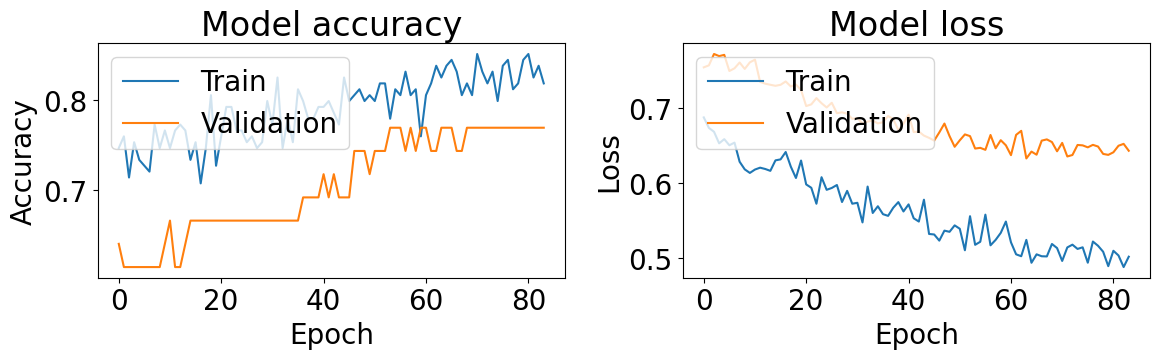

2/2 [==============================] - 0s 11ms/step - loss: 0.5371 - accuracy: 0.7714
Result: use backbone : True, test_accuracy finetune_percent 1.0, fold_number 1, test_results test loss, test acc:[0.5370585322380066, 0.7714285850524902]


------------------------------------------------------------------------
Training for fold 2 ...
--- FASE 1: Addestramento del solo layer finale (Warmup) ---
Epoch 1/15
10/10 [==============================] - 5s 176ms/step - loss: 0.8951 - accuracy: 0.5455 - val_loss: 0.8358 - val_accuracy: 0.7692
Epoch 2/15
10/10 [==============================] - 0s 27ms/step - loss: 0.8540 - accuracy: 0.5325 - val_loss: 0.8250 - val_accuracy: 0.6410
Epoch 3/15
10/10 [==============================] - 0s 28ms/step - loss: 0.8187 - accuracy: 0.6104 - val_loss: 0.7764 - val_accuracy: 0.7692
Epoch 4/15
10/10 [==============================] - 0s 27ms/step - loss: 0.7941 - accuracy: 0.6429 - val_loss: 0.7593 - val_accuracy: 0.7692
Epoch 5/15
10/10 [==============================] - 0s 28ms/step - loss: 0.8039 - accuracy: 0.6883 - val_loss: 0.7374 - val_accuracy: 0.7179
Epoch 6/15
10/10 [==============================] - 0s 27ms/step - loss: 0.7692 - accuracy: 0.7013 - val_loss: 0.7343 - val_accuracy: 0.

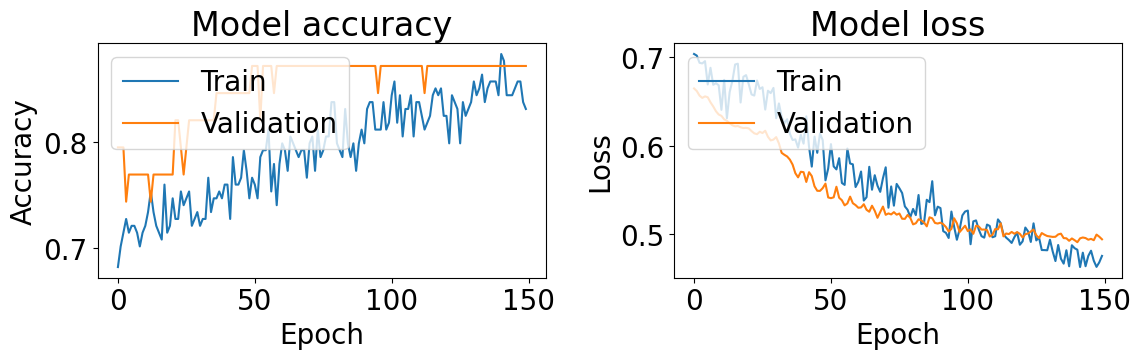

2/2 [==============================] - 0s 11ms/step - loss: 0.4846 - accuracy: 0.8000
Result: use backbone : True, test_accuracy finetune_percent 1.0, fold_number 2, test_results test loss, test acc:[0.48461756110191345, 0.800000011920929]


------------------------------------------------------------------------
Training for fold 3 ...
--- FASE 1: Addestramento del solo layer finale (Warmup) ---
Epoch 1/15
10/10 [==============================] - 7s 184ms/step - loss: 0.8480 - accuracy: 0.6688 - val_loss: 0.8540 - val_accuracy: 0.6410
Epoch 2/15
10/10 [==============================] - 0s 28ms/step - loss: 0.8288 - accuracy: 0.6753 - val_loss: 0.8512 - val_accuracy: 0.6410
Epoch 3/15
10/10 [==============================] - 0s 29ms/step - loss: 0.8178 - accuracy: 0.6753 - val_loss: 0.8332 - val_accuracy: 0.6667
Epoch 4/15
10/10 [==============================] - 0s 28ms/step - loss: 0.8066 - accuracy: 0.7013 - val_loss: 0.8321 - val_accuracy: 0.6667
Epoch 5/15
10/10 [==============================] - 0s 28ms/step - loss: 0.7592 - accuracy: 0.7208 - val_loss: 0.8213 - val_accuracy: 0.6667
Epoch 6/15
10/10 [==============================] - 0s 29ms/step - loss: 0.7679 - accuracy: 0.7143 - val_loss: 0.8171 - val_accuracy: 0.

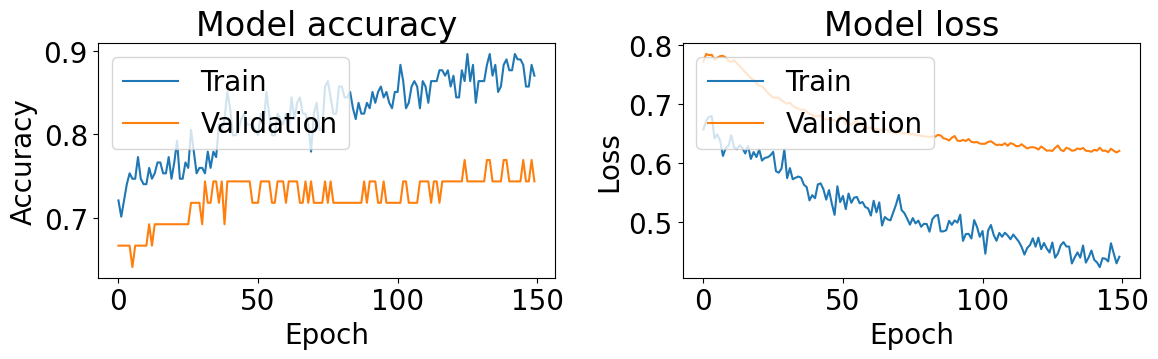

2/2 [==============================] - 0s 11ms/step - loss: 0.4822 - accuracy: 0.8286
Result: use backbone : True, test_accuracy finetune_percent 1.0, fold_number 3, test_results test loss, test acc:[0.48219943046569824, 0.8285714387893677]


------------------------------------------------------------------------
Training for fold 4 ...
--- FASE 1: Addestramento del solo layer finale (Warmup) ---
Epoch 1/15
10/10 [==============================] - 5s 176ms/step - loss: 0.9124 - accuracy: 0.4903 - val_loss: 0.8520 - val_accuracy: 0.7105
Epoch 2/15
10/10 [==============================] - 0s 27ms/step - loss: 0.8606 - accuracy: 0.6710 - val_loss: 0.8051 - val_accuracy: 0.7632
Epoch 3/15
10/10 [==============================] - 0s 14ms/step - loss: 0.8352 - accuracy: 0.6323 - val_loss: 0.8163 - val_accuracy: 0.6842
Epoch 4/15
10/10 [==============================] - 0s 28ms/step - loss: 0.8240 - accuracy: 0.6129 - val_loss: 0.7730 - val_accuracy: 0.7368
Epoch 5/15
10/10 [==============================] - 0s 28ms/step - loss: 0.8112 - accuracy: 0.6452 - val_loss: 0.7475 - val_accuracy: 0.7368
Epoch 6/15
10/10 [==============================] - 0s 14ms/step - loss: 0.7924 - accuracy: 0.7097 - val_loss: 0.7523 - val_accuracy: 0.

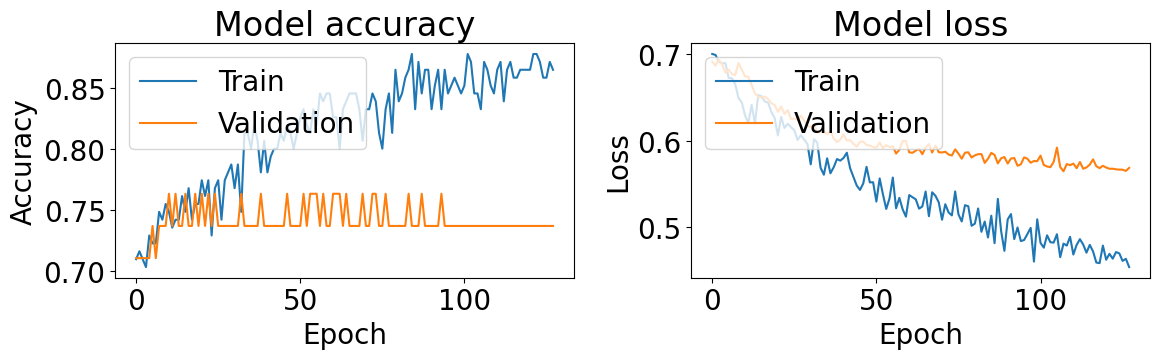

2/2 [==============================] - 0s 11ms/step - loss: 0.5228 - accuracy: 0.7714
Result: use backbone : True, test_accuracy finetune_percent 1.0, fold_number 4, test_results test loss, test acc:[0.5227774381637573, 0.7714285850524902]


------------------------------------------------------------------------
Training for fold 5 ...
--- FASE 1: Addestramento del solo layer finale (Warmup) ---
Epoch 1/15
10/10 [==============================] - 5s 171ms/step - loss: 0.8798 - accuracy: 0.5484 - val_loss: 0.8115 - val_accuracy: 0.7368
Epoch 2/15
10/10 [==============================] - 0s 26ms/step - loss: 0.8398 - accuracy: 0.6581 - val_loss: 0.7727 - val_accuracy: 0.7368
Epoch 3/15
10/10 [==============================] - 0s 28ms/step - loss: 0.7764 - accuracy: 0.6968 - val_loss: 0.7681 - val_accuracy: 0.7632
Epoch 4/15
10/10 [==============================] - 0s 27ms/step - loss: 0.8249 - accuracy: 0.6194 - val_loss: 0.7538 - val_accuracy: 0.7632
Epoch 5/15
10/10 [==============================] - 0s 28ms/step - loss: 0.7811 - accuracy: 0.6968 - val_loss: 0.7225 - val_accuracy: 0.7368
Epoch 6/15
10/10 [==============================] - 0s 27ms/step - loss: 0.7640 - accuracy: 0.7032 - val_loss: 0.7148 - val_accuracy: 0.

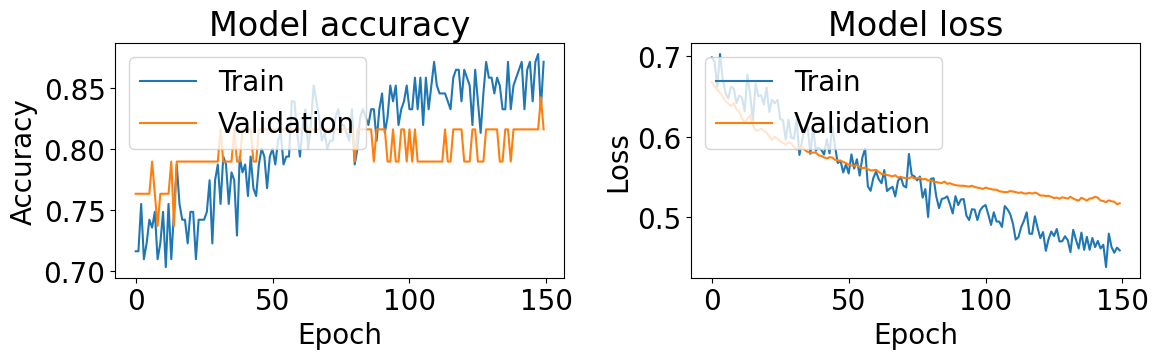

2/2 [==============================] - 0s 11ms/step - loss: 0.4937 - accuracy: 0.8000
Result: use backbone : True, test_accuracy finetune_percent 1.0, fold_number 5, test_results test loss, test acc:[0.4937308132648468, 0.800000011920929]

Running finetune_pct 100% | Backbone: False
------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/150
10/10 [==============================] - 30s 209ms/step - loss: 1.1394 - accuracy: 0.6558 - val_loss: 0.8740 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 2/150
10/10 [==============================] - 1s 50ms/step - loss: 0.6807 - accuracy: 0.8312 - val_loss: 0.8860 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 3/150
10/10 [==============================] - 1s 51ms/step - loss: 0.4975 - accuracy: 0.8701 - val_loss: 1.0145 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 4/150
10/10 [==============================] - 0s 50ms/step - loss: 0.5123 - accuracy: 0.8766 - val_loss: 1.0078 - val_accuracy: 0.589

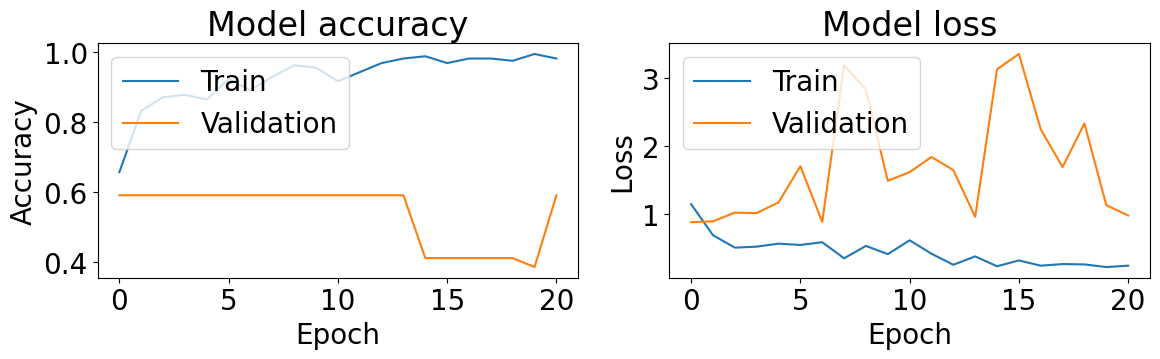

2/2 [==============================] - 0s 11ms/step - loss: 0.8695 - accuracy: 0.6000
Result: use backbone : False, test_accuracy finetune_percent 1.0, fold_number 1, test_results test loss, test acc:[0.8694888353347778, 0.6000000238418579]
------------------------------------------------------------------------
Training for fold 2 ...
Epoch 1/150
10/10 [==============================] - 28s 210ms/step - loss: 1.0869 - accuracy: 0.6883 - val_loss: 0.8908 - val_accuracy: 0.4103 - lr: 1.0000e-04
Epoch 2/150
10/10 [==============================] - 0s 49ms/step - loss: 0.6766 - accuracy: 0.8312 - val_loss: 0.9221 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 3/150
10/10 [==============================] - 1s 64ms/step - loss: 0.5887 - accuracy: 0.8571 - val_loss: 0.8779 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 4/150
10/10 [==============================] - 0s 50ms/step - loss: 0.4893 - accuracy: 0.8766 - val_loss: 1.0275 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 5/150
10/10 [=====

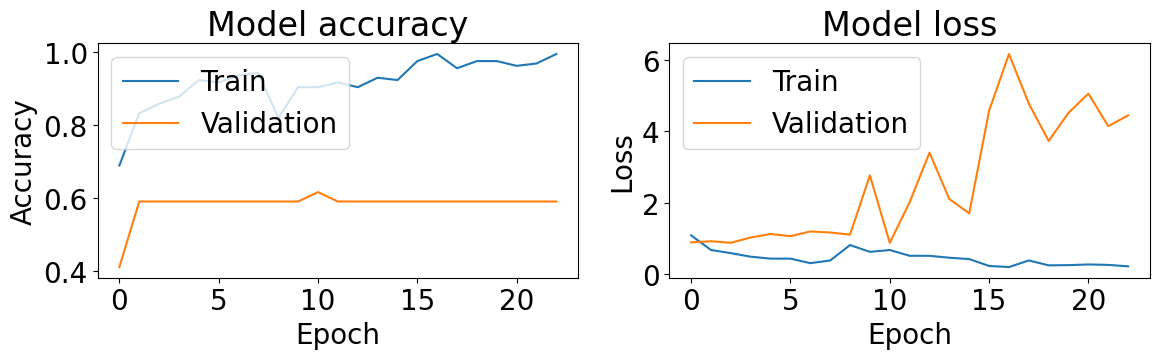

2/2 [==============================] - 0s 12ms/step - loss: 0.8757 - accuracy: 0.6000
Result: use backbone : False, test_accuracy finetune_percent 1.0, fold_number 2, test_results test loss, test acc:[0.875687837600708, 0.6000000238418579]
------------------------------------------------------------------------
Training for fold 3 ...
Epoch 1/150
10/10 [==============================] - 28s 210ms/step - loss: 1.0590 - accuracy: 0.7143 - val_loss: 0.8709 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 2/150
10/10 [==============================] - 1s 54ms/step - loss: 0.6358 - accuracy: 0.8506 - val_loss: 0.9800 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 3/150
10/10 [==============================] - 1s 53ms/step - loss: 0.4575 - accuracy: 0.8896 - val_loss: 1.0808 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 4/150
10/10 [==============================] - 1s 51ms/step - loss: 0.5555 - accuracy: 0.8896 - val_loss: 1.9451 - val_accuracy: 0.5897 - lr: 1.0000e-04
Epoch 5/150
10/10 [======

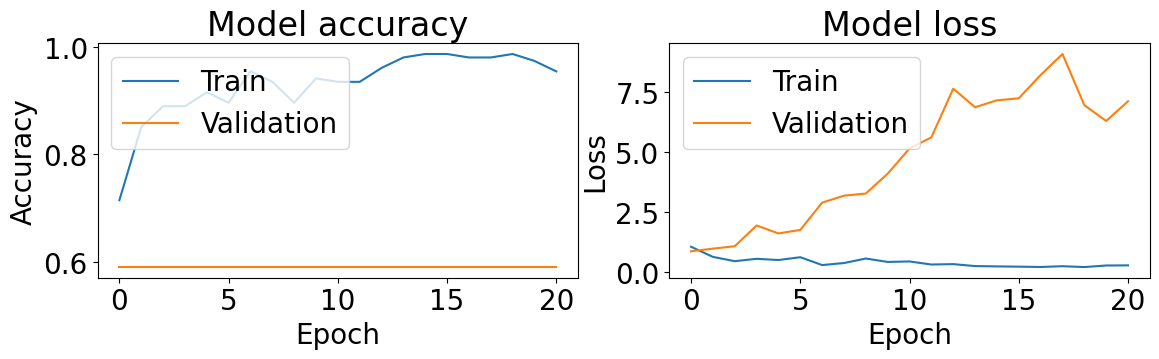

2/2 [==============================] - 0s 11ms/step - loss: 0.8677 - accuracy: 0.6000
Result: use backbone : False, test_accuracy finetune_percent 1.0, fold_number 3, test_results test loss, test acc:[0.8677158951759338, 0.6000000238418579]
------------------------------------------------------------------------
Training for fold 4 ...
Epoch 1/150
10/10 [==============================] - 31s 213ms/step - loss: 1.0799 - accuracy: 0.6774 - val_loss: 0.8820 - val_accuracy: 0.6053 - lr: 1.0000e-04
Epoch 2/150
10/10 [==============================] - 1s 64ms/step - loss: 0.7026 - accuracy: 0.8194 - val_loss: 0.8667 - val_accuracy: 0.6053 - lr: 1.0000e-04
Epoch 3/150
10/10 [==============================] - 0s 50ms/step - loss: 0.6033 - accuracy: 0.8323 - val_loss: 0.9576 - val_accuracy: 0.6053 - lr: 1.0000e-04
Epoch 4/150
10/10 [==============================] - 1s 51ms/step - loss: 0.5255 - accuracy: 0.8839 - val_loss: 1.0697 - val_accuracy: 0.6053 - lr: 1.0000e-04
Epoch 5/150
10/10 [=====

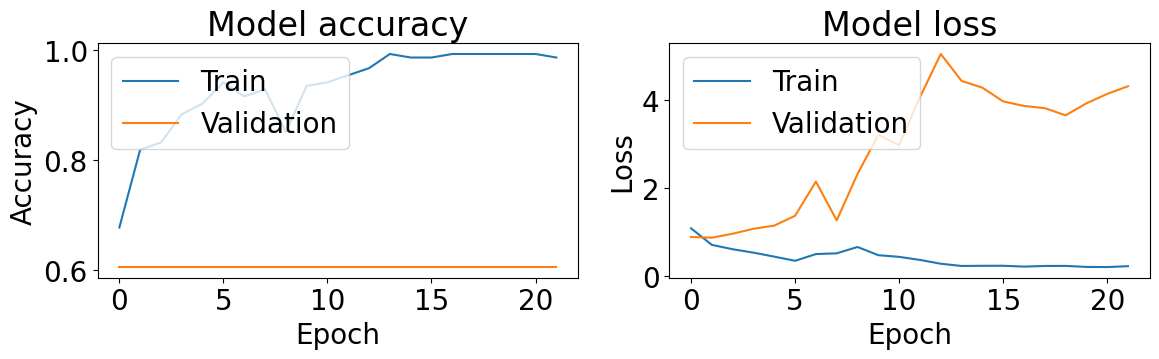

2/2 [==============================] - 0s 12ms/step - loss: 0.8677 - accuracy: 0.6000
Result: use backbone : False, test_accuracy finetune_percent 1.0, fold_number 4, test_results test loss, test acc:[0.867730438709259, 0.6000000238418579]
------------------------------------------------------------------------
Training for fold 5 ...
Epoch 1/150
10/10 [==============================] - 28s 210ms/step - loss: 1.2568 - accuracy: 0.6387 - val_loss: 0.8862 - val_accuracy: 0.5789 - lr: 1.0000e-04
Epoch 2/150
10/10 [==============================] - 1s 67ms/step - loss: 0.5946 - accuracy: 0.8774 - val_loss: 0.8809 - val_accuracy: 0.5789 - lr: 1.0000e-04
Epoch 3/150
10/10 [==============================] - 0s 50ms/step - loss: 0.5238 - accuracy: 0.8839 - val_loss: 0.9815 - val_accuracy: 0.5789 - lr: 1.0000e-04
Epoch 4/150
10/10 [==============================] - 0s 50ms/step - loss: 0.5922 - accuracy: 0.8903 - val_loss: 1.0571 - val_accuracy: 0.5789 - lr: 1.0000e-04
Epoch 5/150
10/10 [======

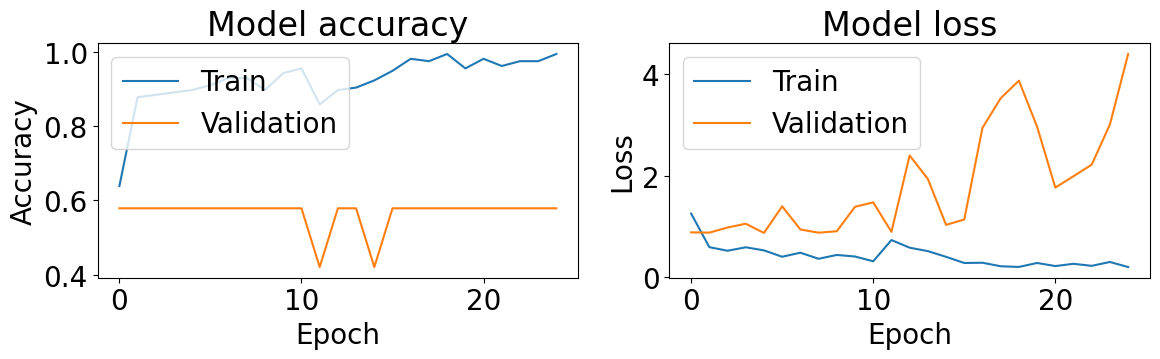

2/2 [==============================] - 0s 11ms/step - loss: 0.8692 - accuracy: 0.6000
Result: use backbone : False, test_accuracy finetune_percent 1.0, fold_number 5, test_results test loss, test acc:[0.8691949844360352, 0.6000000238418579]


In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import random
import os
import numpy as np
import tensorflow as tf

# Imposta i seed per la riproducibilità
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)

temp_model = -1
best_model = None
best_accuracy = 0.0

def do_experiment(finetune_percent = 0.2, use_selfsupervised_backbone = True, nfolds_to_test=5):
  use_reference_warmup = False  # should we train few epochs with x_reference

  if finetune_percent < 1.0:
    xtrainpct, xtestpct, ytrainpct, ytestpct = train_test_split(x_finetune, y_finetune,
                                                                train_size=finetune_percent, random_state=42,
                                                                stratify=y_finetune,
                                                                shuffle=True)
    x_finetune_select, y_finetune_select = xtrainpct, ytrainpct
  else:
    x_finetune_select, y_finetune_select = x_finetune, y_finetune

  # fold validation and testing
  num_folds=5
  kfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

  # K-fold Cross Validation model evaluation
  fold_no = 1
  for train_indices, val_indices in kfold.split(x_finetune_select, y_finetune_select):
      # Generate batches from indices
      xtrain, xval = x_finetune_select[train_indices], x_finetune_select[val_indices]
      ytrain, yval = y_finetune_select[train_indices], y_finetune_select[val_indices]

      if use_selfsupervised_backbone:
        # CARICAMENTO DEL TUO MODELLO PRE-ADDESTRATO
        bm_model_loaded = keras.models.load_model("/content/drive/My Drive/Tesi_Raman/Models/PreTrain/BarlowTwins/1000pt/FullRange/Min-Max/exp_1/ramanfoundation_pretrained_model.h5")
        bm_model_loaded.trainable = False # FASE 1: Congeliamo tutto
      else:
        bm_model_loaded = build_twin() # use random weights model
        bm_model_loaded.trainable = True

      model = tf.keras.models.Sequential([
        bm_model_loaded,
        tf.keras.layers.GaussianNoise(0.01), # <-- AGGIUNTA NOISE: previene la memorizzazione esatta delle feature
        tf.keras.layers.Dropout(0.6), # <-- AUMENTATO PER COMBATTERE L'OVERFITTING
        tf.keras.layers.Dense(
            2,
            activation="softmax",
            kernel_regularizer=tf.keras.regularizers.l2(0.05) # <-- AUMENTATA L2
        )
      ])

      # Calcolo dei pesi delle classi
      classes = np.unique(ytrain)
      c_weights = compute_class_weight('balanced', classes=classes, y=ytrain)
      class_weights_dict = dict(zip(classes, c_weights))

      print('------------------------------------------------------------------------')
      print(f'Training for fold {fold_no} ...')

      # FASE 1: Linear Probing
      if use_selfsupervised_backbone:
          print("--- FASE 1: Addestramento del solo layer finale (Warmup) ---")
          model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
          model.fit(xtrain, ytrain,
                    validation_data=(xval, yval),
                    batch_size=16,
                    epochs=15,
                    class_weight=class_weights_dict,
                    callbacks=[
                        keras.callbacks.EarlyStopping(
                            monitor='val_loss', # <-- MONITORIAMO LA LOSS, non l'accuracy
                            patience=5,
                            restore_best_weights=True
                        )
                    ],
                    verbose=1)

          print("--- FASE 2: Fine-Tuning Sicuro (BatchNormalization BLOCCATE) ---")
          bm_model_loaded.trainable = True

          # Scongeliamo SOLO L'ULTIMO 10% dei layer convoluzionali
          freeze_until = int(len(bm_model_loaded.layers) * 0.90)
          for layer in bm_model_loaded.layers[:freeze_until]:
              layer.trainable = False

          # IL TRUCCO CRITICO: Ripercorriamo tutti i layer per assicurarci che i layer BatchNormalization restino CONGELATI
          for layer in bm_model_loaded.layers:
              if isinstance(layer, tf.keras.layers.BatchNormalization) or 'batch_normalization' in layer.name.lower():
                  layer.trainable = False

          final_lr = 0.00001 # Learning rate bassissimo
      else:
          final_lr = 0.0001

      # Compilazione finale
      model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=final_lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

      history = model.fit(xtrain, ytrain,
                          validation_data=(xval, yval),
                          batch_size=16,
                          epochs=150,
                          class_weight=class_weights_dict,
                          callbacks=[
                              keras.callbacks.EarlyStopping(
                                  monitor='val_loss', # <-- MONITORIAMO LA LOSS per fermarci prima dell'overfitting
                                  patience=20,
                                  restore_best_weights=True
                              ),
                              keras.callbacks.ReduceLROnPlateau(
                                  monitor='val_loss',
                                  factor=0.5,
                                  patience=10,
                                  min_lr=0.0000001
                              )
                          ]
                          )

      # Plot training history
      import matplotlib.pyplot as plt
      plt.figure(figsize=(12, 4))
      plt.subplot(1, 2, 1)
      plt.plot(history.history['accuracy'])
      plt.plot(history.history['val_accuracy'])
      plt.title('Model accuracy')
      plt.ylabel('Accuracy')
      plt.xlabel('Epoch')
      plt.legend(['Train', 'Validation'], loc='upper left')
      plt.subplot(1, 2, 2)
      plt.plot(history.history['loss'])
      plt.plot(history.history['val_loss'])
      plt.title('Model loss')
      plt.ylabel('Loss')
      plt.xlabel('Epoch')
      plt.legend(['Train', 'Validation'], loc='upper left')
      plt.tight_layout()
      plt.show()

      result = model.evaluate(x_test, y_test)
      result_str = "test loss, test acc:" + str(result)
      print(f"Result: use backbone : {use_selfsupervised_backbone}, test_accuracy finetune_percent {finetune_percent}, fold_number {fold_no}, test_results {result_str}")
      result_dict = dict(zip(model.metrics_names, result))
      result_dict_str = str(result_dict)

      file_name = f"result_{int(finetune_percent * 100)}_backbone_{use_selfsupervised_backbone}"
      with open(file_name, "a") as file:
          file.write("\n"+result_dict_str)

      global temp_model, best_model, best_accuracy
      temp_model = model

      if result_dict['accuracy'] > best_accuracy:
          best_accuracy = result_dict['accuracy']
          best_model = model

      fold_no = fold_no + 1
      if fold_no > nfolds_to_test:
        return

# Pulizia file precedenti per non inquinare i risultati medi
import os
for f in ["result_100_backbone_True", "result_100_backbone_False"]:
    if os.path.exists(f):
        os.remove(f)

# Esegue solo per il 100% dei dati
for pct in [100]:
  for usebackbone in [True, False]:
    print (f"\n=========================================")
    print (f"Running finetune_pct {pct}% | Backbone: {usebackbone}")
    print (f"=========================================")
    do_experiment(pct/100.0, usebackbone,  nfolds_to_test=5)


In [23]:
import ast
import os
import numpy as np

print("=== AVERAGE ACCURACY SUMMARY ===\n")

# Analizza solo il file dei risultati per il 100% dei dati
for pct in [100]:
    for usebackbone in [True, False]:
        file_name = f"result_{pct}_backbone_{usebackbone}"
        if os.path.exists(file_name):
            with open(file_name, "r") as f:
                lines = f.readlines()
                accuracies = []
                for line in lines:
                    line = line.strip()
                    if line:
                        try:
                            # Convert the dictionary string into a real Python dictionary
                            result_dict = ast.literal_eval(line)
                            accuracies.append(result_dict['accuracy'])
                        except:
                            pass

                if accuracies:
                    avg_acc = np.mean(accuracies)
                    std_acc = np.std(accuracies)
                    print(f"-> Data used: {pct}% | Pre-trained (Backbone): {usebackbone}")
                    print(f"   Average Test Accuracy: {avg_acc*100:.2f}% (± {std_acc*100:.2f}%)\n")
        else:
            print(f"File {file_name} not found.\n")


=== AVERAGE ACCURACY SUMMARY ===

-> Data used: 100% | Pre-trained (Backbone): True
   Average Test Accuracy: 79.43% (± 2.14%)

-> Data used: 100% | Pre-trained (Backbone): False
   Average Test Accuracy: 60.00% (± 0.00%)



In [24]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 20}) # Adjust the value (20) as needed

Confusion matrix plot used in Figure 8

2/2 [==============================] - 1s 9ms/step


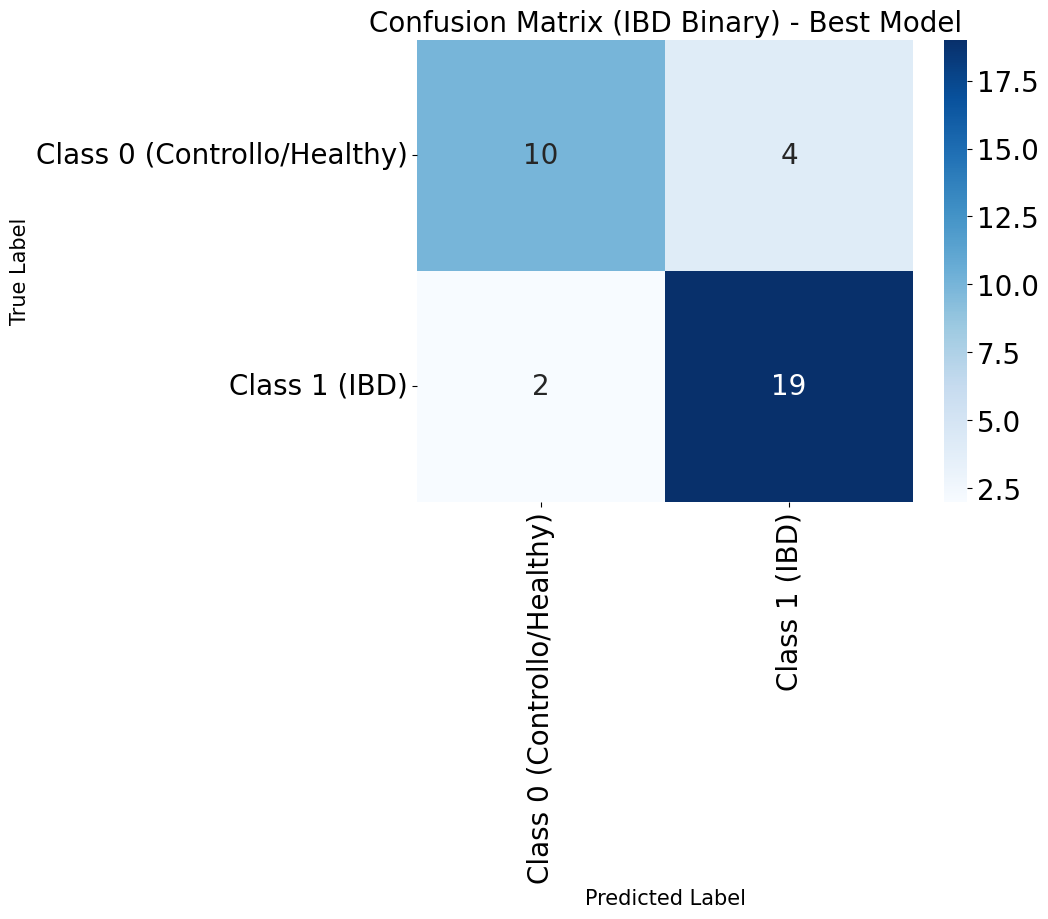

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Utilizza best_model se è stato calcolato, altrimenti ripiega su temp_model per retrocompatibilità
model_to_evaluate = best_model if 'best_model' in globals() and best_model is not None else temp_model

y_pred = np.argmax(model_to_evaluate.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6)) # Dimensioni ridotte per matrice 2x2
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CLASSES[i] for i in range(2)],
            yticklabels=[CLASSES[i] for i in range(2)])
plt.xlabel("Predicted Label", fontsize=FONTSIZE_AXIS)
plt.ylabel("True Label", fontsize=FONTSIZE_AXIS)
plt.title("Confusion Matrix (IBD Binary) - Best Model", fontsize=FONTSIZE_TITLE)
plt.show()
